In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

sales = pd.read_csv('../dataset/raw/sales.csv', parse_dates=['Date'])
web_traffic = pd.read_csv('../dataset/raw/web_traffic.csv', parse_dates=['date'])

sales['Gross_Profit'] = sales['Revenue'] - sales['COGS']
sales['Gross_Margin'] = (sales['Gross_Profit'] / sales['Revenue']) * 100
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month

# Gom nhóm theo tháng để vẽ biểu đồ mượt hơn
monthly_sales = sales.resample('ME', on='Date').sum().reset_index()

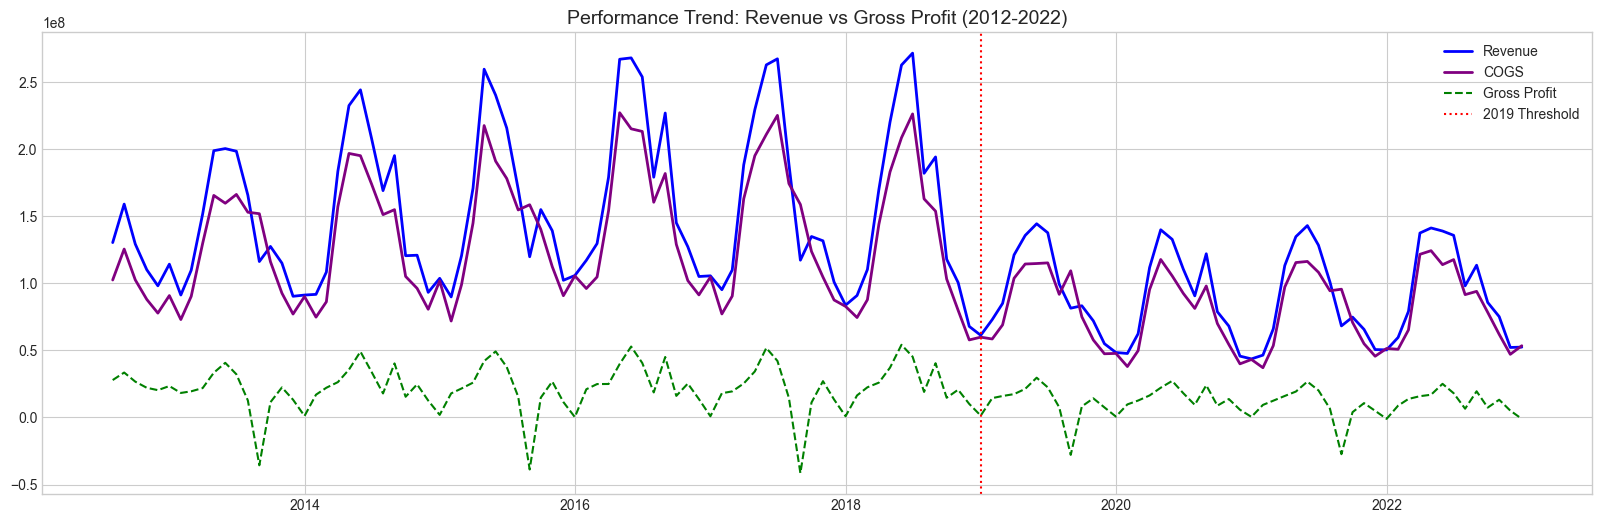

In [14]:
plt.figure(figsize=(20, 6))
plt.plot(monthly_sales['Date'], monthly_sales['Revenue'], label='Revenue', color='blue', linewidth=2)
plt.plot(monthly_sales['Date'], monthly_sales['COGS'], label='COGS', color='purple', linewidth=2)
plt.plot(monthly_sales['Date'], monthly_sales['Gross_Profit'], label='Gross Profit', color='green', linestyle='--')
plt.axvline(pd.Timestamp('2019-01-01'), color='red', linestyle=':', label='2019 Threshold')

plt.title('Performance Trend: Revenue vs Gross Profit (2012-2022)', fontsize=14)
plt.legend()
plt.show()

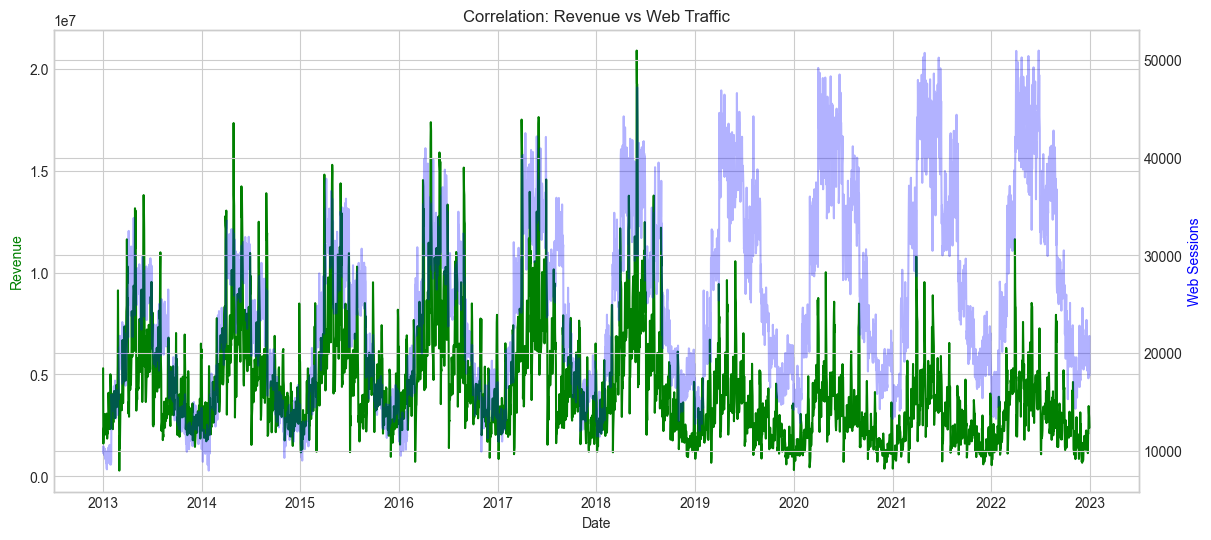

In [15]:
# Kết hợp Sales và Web Traffic theo ngày
traffic_daily = web_traffic.groupby('date')[['sessions', 'page_views']].sum().reset_index()
merged_data = pd.merge(sales, traffic_daily, left_on='Date', right_on='date', how='inner')

# Tính tỷ lệ chuyển đổi giả định (Orders/Sessions - ở đây tạm lấy Revenue/Sessions để xem hiệu suất tiền tệ)
merged_data['Rev_per_Session'] = merged_data['Revenue'] / merged_data['sessions']

fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()
ax1.plot(merged_data['Date'], merged_data['Revenue'], color='g', label='Revenue')
ax2.plot(merged_data['Date'], merged_data['sessions'], color='b', alpha=0.3, label='Web Sessions')

ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue', color='g')
ax2.set_ylabel('Web Sessions', color='b')
plt.title('Correlation: Revenue vs Web Traffic')
plt.show()

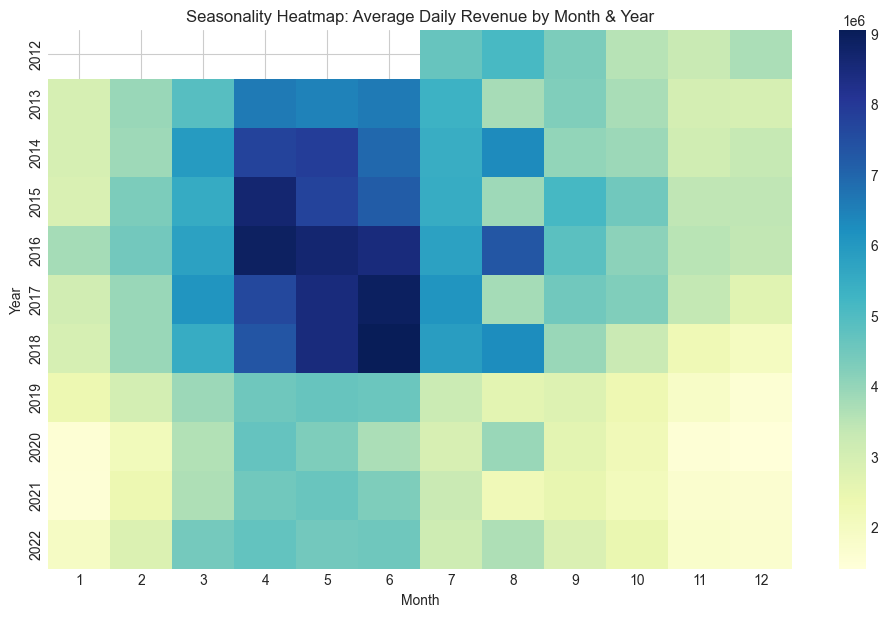

In [16]:
pivot_rev = sales.pivot_table(values='Revenue', index='Year', columns='Month', aggfunc='mean')

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_rev, cmap='YlGnBu', annot=False)
plt.title('Seasonality Heatmap: Average Daily Revenue by Month & Year')
plt.show()

Hiệu suất trên mỗi phiên truy cập trước 2019: 235.01
Hiệu suất trên mỗi phiên truy cập sau 2019: 104.31
Mức sụt giảm hiệu suất: 55.62%


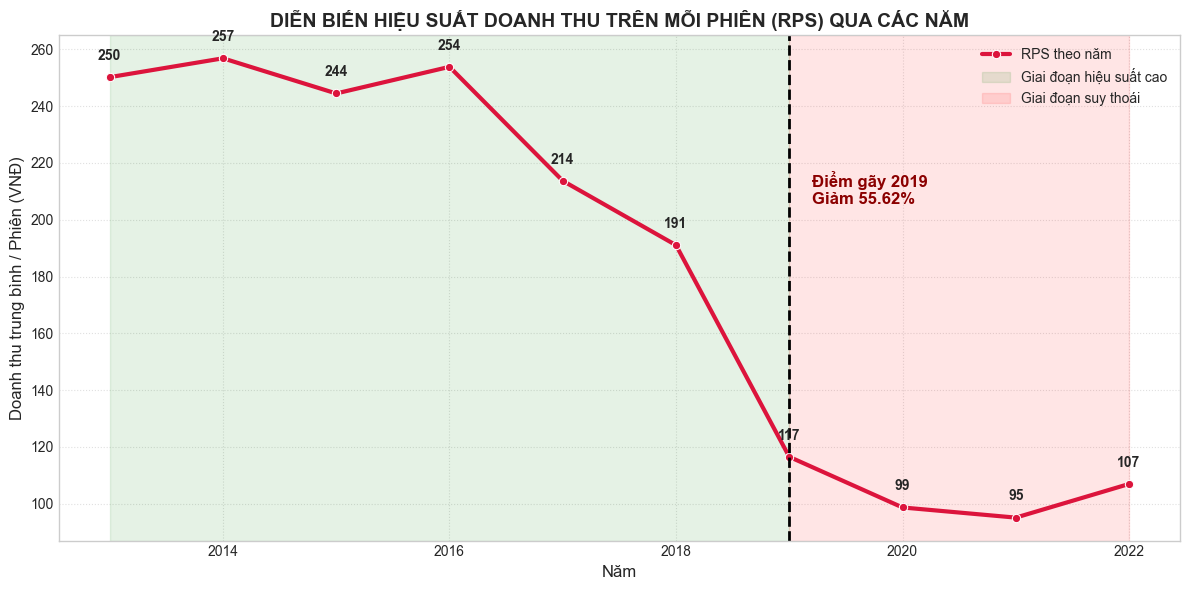

In [17]:
# Tính toán Conversion Rate giả định (Revenue / Sessions)
merged_data['Rev_per_Session'] = merged_data['Revenue'] / merged_data['sessions']

before_2019 = merged_data[merged_data['Date'].dt.year < 2019]['Rev_per_Session'].mean()
after_2019 = merged_data[merged_data['Date'].dt.year >= 2019]['Rev_per_Session'].mean()

print(f"Hiệu suất trên mỗi phiên truy cập trước 2019: {before_2019:.2f}")
print(f"Hiệu suất trên mỗi phiên truy cập sau 2019: {after_2019:.2f}")
print(f"Mức sụt giảm hiệu suất: {((before_2019 - after_2019)/before_2019)*100:.2f}%")

# 1. Tính toán RPS theo từng năm để đảm bảo tính công bằng
merged_data['Year'] = merged_data['Date'].dt.year
yearly_rps = merged_data.groupby('Year')['Rev_per_Session'].mean()

# 2. Vẽ biểu đồ diễn biến RPS
plt.figure(figsize=(12, 6))

# Vẽ đường biểu diễn chính
sns.lineplot(x=yearly_rps.index, y=yearly_rps.values, marker='o', color='crimson', linewidth=3, label='RPS theo năm')

# Tô màu vùng trước và sau 2019 để nhấn mạnh sự khác biệt
plt.axvspan(2013, 2019, color='green', alpha=0.1, label='Giai đoạn hiệu suất cao')
plt.axvspan(2019, 2022, color='red', alpha=0.1, label='Giai đoạn suy thoái')

# Đánh dấu mốc 2019
plt.axvline(x=2019, color='black', linestyle='--', linewidth=2)
plt.text(2019.2, yearly_rps.max()*0.8, 'Điểm gãy 2019\nGiảm 55.62%', color='darkred', fontweight='bold', fontsize=12)

# Tùy chỉnh thẩm mỹ
plt.title('DIỄN BIẾN HIỆU SUẤT DOANH THU TRÊN MỖI PHIÊN (RPS) QUA CÁC NĂM', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Doanh thu trung bình / Phiên (VNĐ)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Hiển thị giá trị cụ thể tại các điểm nút
for x, y in zip(yearly_rps.index, yearly_rps.values):
    plt.text(x, y + 5, f'{y:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

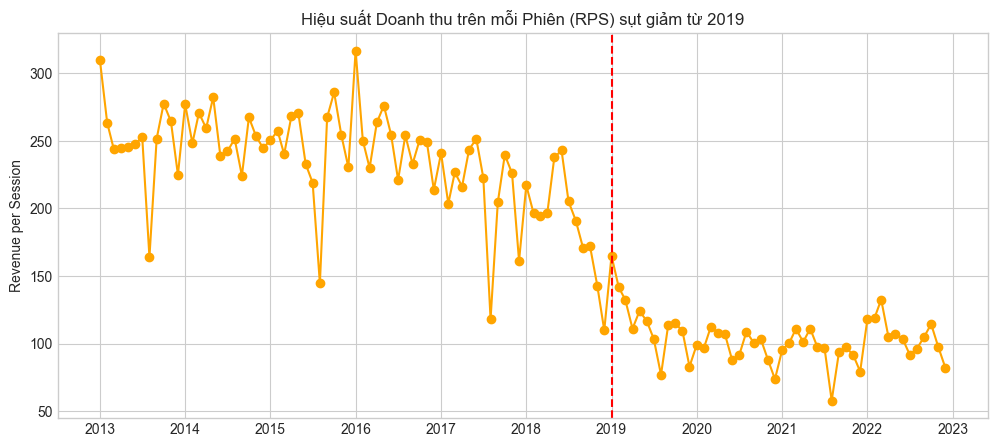

In [18]:
# 1. Chuẩn bị dữ liệu Revenue và Traffic
sales['Date'] = pd.to_datetime(sales['Date'])
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

daily_traffic = web_traffic.groupby('date')['sessions'].sum().reset_index()
df_merged = pd.merge(sales, daily_traffic, left_on='Date', right_on='date')

# 2. Tính Revenue per Session (RPS) theo tháng
df_merged['Month_Year'] = df_merged['Date'].dt.to_period('M')
monthly_perf = df_merged.groupby('Month_Year').agg({
    'Revenue': 'sum',
    'sessions': 'sum'
}).reset_index()

monthly_perf['RPS'] = monthly_perf['Revenue'] / monthly_perf['sessions']
monthly_perf['Month_Year'] = monthly_perf['Month_Year'].dt.to_timestamp()

# Vẽ biểu đồ hiệu suất
plt.figure(figsize=(12, 5))
plt.plot(monthly_perf['Month_Year'], monthly_perf['RPS'], color='orange', marker='o')
plt.axvline(pd.Timestamp('2019-01-01'), color='red', linestyle='--')
plt.title('Hiệu suất Doanh thu trên mỗi Phiên (RPS) sụt giảm từ 2019')
plt.ylabel('Revenue per Session')
plt.show()

In [19]:
products = pd.read_csv('../dataset/raw/products.csv')
products['Margin_Rate'] = (products['price'] - products['cogs']) / products['price']

order_items = pd.read_csv('../dataset/raw/order_items.csv', low_memory=False)
orders = pd.read_csv('../dataset/raw/orders.csv', parse_dates=['order_date'])

orders_after_2019 = orders[orders['order_date'] >= '2019-01-01']
items_after_2019 = pd.merge(orders_after_2019, order_items, on='order_id')
items_with_margin = pd.merge(items_after_2019, products[['product_id', 'Margin_Rate']], on='product_id')

avg_margin_after_2019 = items_with_margin['Margin_Rate'].mean()
print(f"Biên lợi nhuận gộp trung bình của các sản phẩm bán ra sau 2019: {avg_margin_after_2019:.2%}")

Biên lợi nhuận gộp trung bình của các sản phẩm bán ra sau 2019: 20.22%


In [20]:
# Tìm những sản phẩm có Margin tốt và Rating cao (từ reviews.csv)
reviews = pd.read_csv('../dataset/raw/reviews.csv')
avg_ratings = reviews.groupby('product_id')['rating'].mean().reset_index()

strategic_products = pd.merge(products, avg_ratings, on='product_id')
# Tiêu chí: Lợi nhuận > 20% và Rating > 4 sao
recommendations = strategic_products[(strategic_products['Margin_Rate'] > 0.2) & (strategic_products['rating'] > 4)]

print("Top 5 sản phẩm đề xuất đẩy mạnh Marketing:")
print(recommendations[['product_name', 'category', 'Margin_Rate', 'rating']].head(5))

Top 5 sản phẩm đề xuất đẩy mạnh Marketing:
        product_name    category  Margin_Rate    rating
7   SaigonFlex UC-09  Streetwear       0.2475  4.200000
10  SaigonFlex UC-12  Streetwear       0.3432  4.384615
26  SaigonFlex UC-33  Streetwear       0.2757  4.285714
47  SaigonFlex UC-57  Streetwear       0.3652  4.086957
52  SaigonFlex UC-65  Streetwear       0.4920  4.075630


Lượng hàng bán ra trong Quý 2 chi tiết theo từng năm:
category  Casual   GenZ  Outdoor  Streetwear
Year                                        
2013        2458   5628    51203       69201
2014        2925   6472    50526       79416
2015        3238   6265    46220       83950
2016        4632   7238    39943       94189
2017        4867   7386    37209       88216
2018        7608  13315    27579       90600
2019        3507   3802    16849       43432
2020        2915   3691    14441       38429
2021        3563   4717    10845       40255
2022        3820   5155    10940       39439


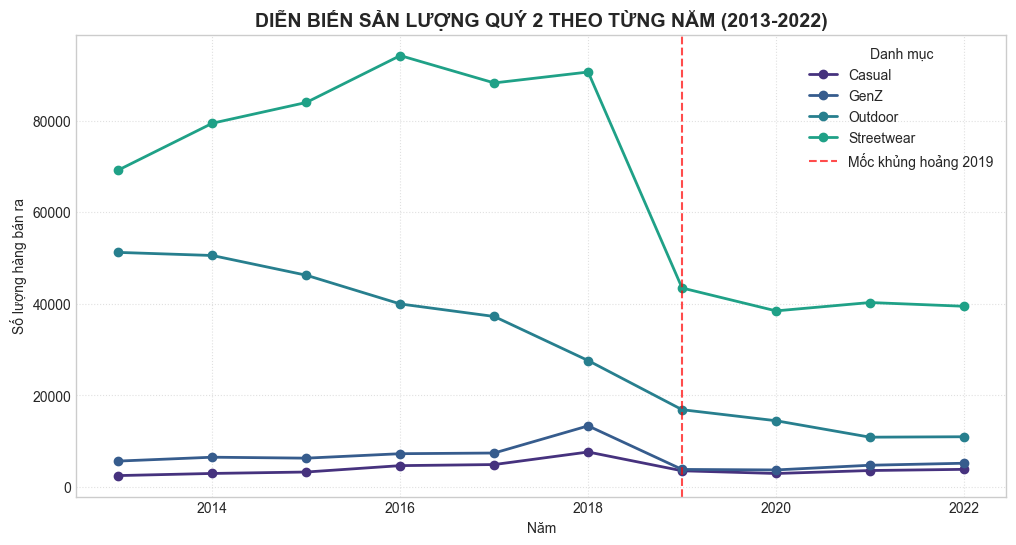

In [21]:
# 1. Chuẩn bị dữ liệu (Giữ nguyên phần xử lý thời gian của bạn)
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Month'] = orders['order_date'].dt.month
orders['Year'] = orders['order_date'].dt.year

# 2. Lọc dữ liệu Quý 2 (Tháng 4, 5, 6)
q2_orders = orders[orders['Month'].isin([4, 5, 6])]

# 3. Kết hợp với Item và Product để xem Category
q2_details = pd.merge(q2_orders, order_items, on='order_id')
q2_details = pd.merge(q2_details, products, on='product_id')

# 4. SỬA ĐỔI: So sánh lượng hàng bán ra theo TỪNG NĂM và Category
category_yearly_comparison = q2_details.groupby(['Year', 'category'])['quantity'].sum().unstack().fillna(0)

# In kết quả dạng bảng để kiểm tra con số cụ thể từng năm
print("Lượng hàng bán ra trong Quý 2 chi tiết theo từng năm:")
print(category_yearly_comparison)

# 5. TRỰC QUAN HÓA: Vẽ biểu đồ đường để thấy "điểm gãy" 2019 rõ ràng nhất
import matplotlib.pyplot as plt

category_yearly_comparison.plot(kind='line', marker='o', figsize=(12, 6), linewidth=2)
plt.axvline(x=2019, color='red', linestyle='--', alpha=0.7, label='Mốc khủng hoảng 2019')
plt.title('DIỄN BIẾN SẢN LƯỢNG QUÝ 2 THEO TỪNG NĂM (2013-2022)', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng hàng bán ra')
plt.xlabel('Năm')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Danh mục')
plt.show()


% Đơn hàng có khuyến mãi trong Quý 2 qua các năm:
Year
2013    23.340075
2014    23.836549
2015    25.004828
2016    22.496773
2017    23.712045
2018    21.784387
2019    23.635878
2020    25.579296
2021    24.813052
2022    26.145268
Name: Has_Promo, dtype: float64


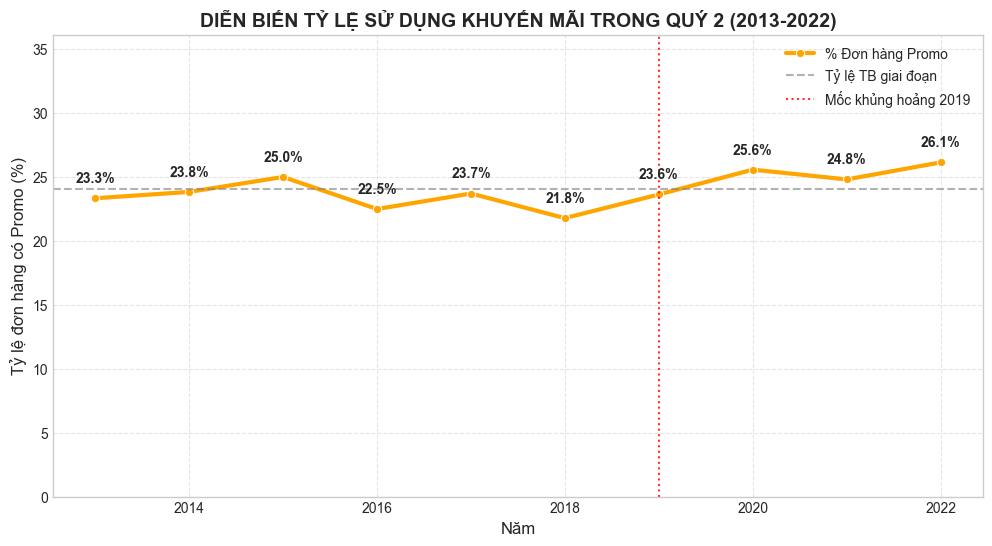

In [22]:

# 1. Tính toán tỷ lệ đơn hàng có khuyến mãi trong Quý 2 theo từng năm
q2_details['Has_Promo'] = q2_details['promo_id'].notna()
promo_trend = q2_details.groupby('Year')['Has_Promo'].mean() * 100

print("\n% Đơn hàng có khuyến mãi trong Quý 2 qua các năm:")
print(promo_trend)

# 2. Vẽ biểu đồ diễn biến Khuyến mãi
plt.figure(figsize=(12, 6))

# Vẽ đường line thể hiện xu hướng
sns.lineplot(x=promo_trend.index, y=promo_trend.values, marker='o', color='orange', linewidth=3, label='% Đơn hàng Promo')

# Vẽ đường trung bình (Baseline) để so sánh sự biến động
plt.axhline(y=promo_trend.mean(), color='gray', linestyle='--', alpha=0.6, label='Tỷ lệ TB giai đoạn')

# Đánh dấu mốc 2019 để đối chiếu với sự sụt giảm sản lượng
plt.axvline(x=2019, color='red', linestyle=':', alpha=0.8, label='Mốc khủng hoảng 2019')

# Tùy chỉnh biểu đồ
plt.title('DIỄN BIẾN TỶ LỆ SỬ DỤNG KHUYẾN MÃI TRONG QUÝ 2 (2013-2022)', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tỷ lệ đơn hàng có Promo (%)', fontsize=12)
plt.ylim(0, max(promo_trend.values) + 10) # Tạo khoảng trống phía trên cho dễ nhìn
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Hiển thị giá trị số lên các điểm nút
for x, y in zip(promo_trend.index, promo_trend.values):
    plt.text(x, y + 1, f'{y:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


Danh sách 'Ngôi sao' chiến lược cho Quý 2:
          product_name    category  quantity  Margin_Rate
588   SaigonFlex UM-43  Streetwear      5364     0.429900
539   SaigonFlex UC-55  Streetwear      2510     0.257661
196  HanoiStreet YY-10        GenZ      2480     0.376700
882   VietMotion UE-06  Streetwear      2404     0.214700
548   SaigonFlex UC-80  Streetwear      2167     0.414900


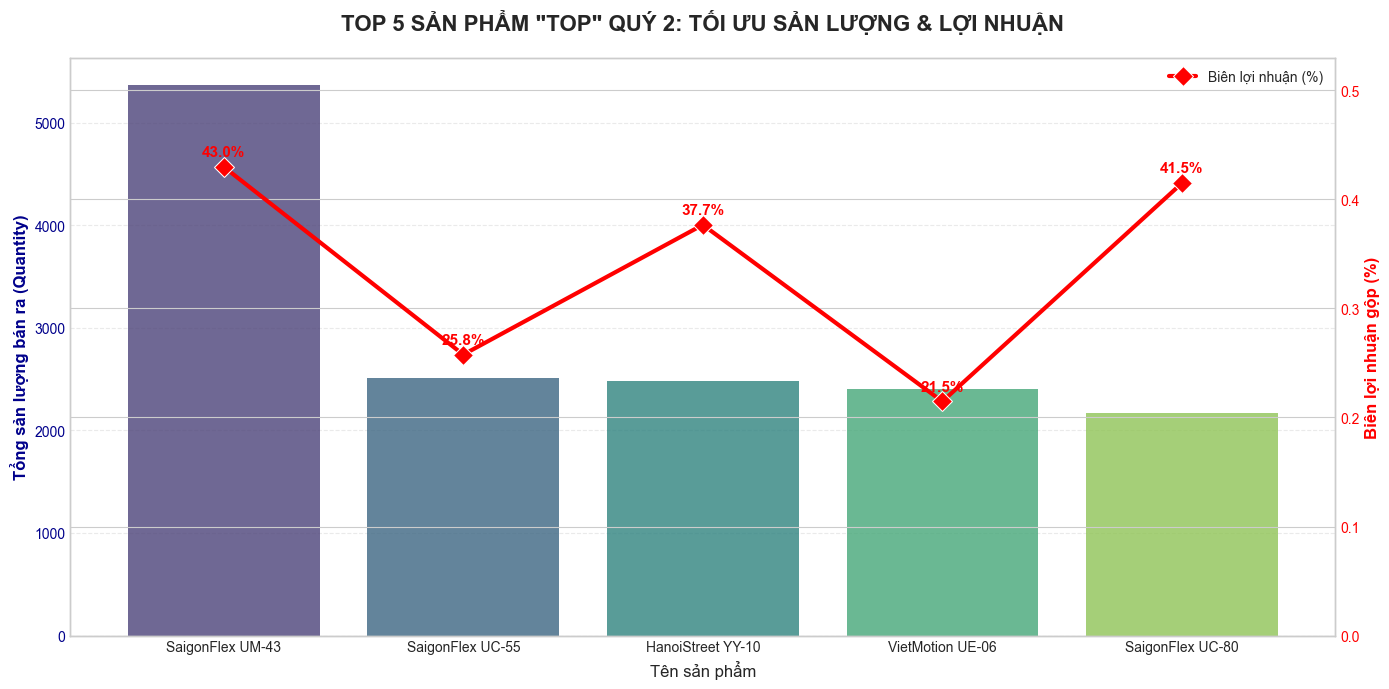

In [23]:
# 1. Lọc sản phẩm Quý 2 sau 2019 và tính toán các chỉ số
q2_after_2019 = q2_details[q2_details['Year'] >= 2019]
star_products = q2_after_2019.groupby(['product_name', 'category']).agg({
    'quantity': 'sum',
    'Margin_Rate': 'mean'
}).reset_index()

# 2. Lọc sản phẩm có Margin > 20% và lấy Top 5 về sản lượng
top_stars = star_products[star_products['Margin_Rate'] > 0.2].sort_values(by='quantity', ascending=False).head(5)

print("\nDanh sách 'Ngôi sao' chiến lược cho Quý 2:")
print(top_stars)

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(x='product_name', y='quantity', hue='product_name', data=top_stars, ax=ax1, palette='viridis', alpha=0.8, legend=False)
ax1.set_ylabel('Tổng sản lượng bán ra (Quantity)', fontsize=12, fontweight='bold', color='darkblue')
ax1.set_xlabel('Tên sản phẩm', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkblue')

ax2 = ax1.twinx()
sns.lineplot(x='product_name', y='Margin_Rate', data=top_stars, ax=ax2, marker='D', color='red', linewidth=3, markersize=10, label='Biên lợi nhuận (%)')

ax2.set_ylabel('Biên lợi nhuận gộp (%)', fontsize=12, fontweight='bold', color='red')
ax2.set_ylim(0, max(top_stars['Margin_Rate']) + 0.1) 
ax2.tick_params(axis='y', labelcolor='red')

for i, row in top_stars.reset_index().iterrows():
    ax2.text(i, row['Margin_Rate'] + 0.01, f"{row['Margin_Rate']:.1%}", 
             color='red', ha='center', fontweight='bold', fontsize=11)

# Hoàn thiện biểu đồ
plt.title('TOP 5 SẢN PHẨM "TOP" QUÝ 2: TỐI ƯU SẢN LƯỢNG & LỢI NHUẬN', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()